# Backtesting a Hierarchical Risk Parity (HRP) and equal weighted strategy with a momentum portifolio rolling selected

**What ?** Hierarchical Risk Parity (HRP) is a portfolio allocation technique that leverages hierarchical clustering to create diversified portfolios. HRP addresses instability problems found in other methods like Mean-Variance Optimization by organizing assets into a hierarchical structure based on their correlations and then allocating risk according to this hierarchy. Given its properties, in this work HRP will be applied to weight a portifolio constructed based on momentum monthly rebalanced.

**Why ?** There are some advantages to using HRP for portfolio weighting, such as:
- *Stability:* By focusing on hierarchical relationships, HRP reduces the impact of estimation errors in the covariance matrix.
- *Diversification:* The technique naturally leads to a diversified portfolio by ensuring that risk is allocated across different clusters.
- *No Need for Inverse Covariance:* Unlike MVO, HRP does not require the inversion of the covariance matrix, making it more robust in cases of highly correlated assets.

**How ?** Starting with the 100 tickers listed in the IBRX100 Brazilian index composition on july 2024, we will download their prices from the Yahoo Finance library for the period from 2017 to June 2024. After some data cleaning, the twelve-month returns will be calculated daily for each ticker. The top 10 tickers with the highest monthly returns will be selected to compose our portfolio for the following month, applying a momentum strategy. Once the 10 assets are selected, each ticker's weight will be determined using an HRP strategy with the PyPortfolioOpt library. For comparison, an equal-weighted strategy will also be constructed. Finally, the returns, volatility, and Sharpe Ratio will be compared between the HRP and equal-weighted methods. The Ibovespa results will also be used in the final comparison to evaluate the technique against a market benchmark.


<img src="https://lh3.googleusercontent.com/d/1_appeEjZSuMxMfcWfzuUZkViX1KAh-lU" alt="HRP_momentum_strategy" width="500" align="center">

**Results obtained:** 


In the end, the HRP-weighted portfolio slightly underperformed the equal-weighted strategy, with a Sharpe ratio of -1.22 compared to -1.17 for the equal-weighted approach. The cumulative returns for HRP reached 216%, while the equal-weighted portfolio achieved 211%. The Sharpe ratio leads us to conclude that the HRP approach does not appear to add significant value over the equal-weighting method, particularly when considering the complexity involved in both approaches.

<a id="0"></a>
# Table of Contents

1. [Import Libraries](#1)
2. [Import daily prices](#2)
3. [Data cleaning and transformation](#3)
4. [Studying the Hierarchial Risk Parity (HRP) metodology](#5)<br>
    4.1 [Step 1 - Hierarchical clustering](#6)<br>
    4.1 [Step 2 - Quasi-Diagonalisation (Matrix seriation)](#7)<br>
    4.2 [Step 3 - Recursive Bisection and weighting](#8)<br>
5. [Backtesting the strategy](#9)<br>
    5.1 [Selecting top 10 assets for each month by its previous returns (Momentum)](#10)<br>
    5.2 [Calculating the portifolio quota](#11)<br>
    5.3 [Calculating the HRP over the montly portifolios selected](#12)<br>
    5.4 [Backtesting by HRP weights method](#13)<br>
    5.5 [Backtesting by Equal Weighted method](#14)<br>
6. [Comparing results](#15)<br>
    6.1 [Final returns](#16)<br>
    6.2 [Daily volatility](#17)<br>
    6.3 [Anualized volatility](#18)<br>
7. [Comments and further discutions](#19)

<a id="1"></a>
# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from collections import OrderedDict

import yfinance as yf
import pypfopt
from pypfopt import HRPOpt
from pypfopt import plotting

<a id="2"></a>
# Import daily prices
[←](#0)

##### Import IBRX100 tickers composition

In [2]:
 script_directory = os.getcwd() #getting the script directory path
directory_path = os.path.join(script_directory,'IBRX100_20240603.csv') # IBRX100 index composition downloaded from B3 website

# import IBRX100 tickers compositions
df_ibrx100 = pd.read_csv(directory_path, sep = ';', encoding = 'Latin-1')
df_ibrx100['tickers'] = df_ibrx100['Código'] + '.SA'
df_ibrx100 = df_ibrx100[['tickers']]

# show all tickers from IBRX100
ticker_df = pd.DataFrame(df_ibrx100['tickers'].sort_values().values.reshape(10, 10))
#pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) 
print(ticker_df)

           0          1         2          3         4          5          6         7          8         9
0   ABEV3.SA   ALOS3.SA  ALPA4.SA   ARZZ3.SA  ASAI3.SA   AURE3.SA   AZUL4.SA  B3SA3.SA   BBAS3.SA  BBDC3.SA
1   BBDC4.SA   BBSE3.SA  BEEF3.SA  BPAC11.SA  BRAP4.SA   BRFS3.SA   BRKM5.SA  CCRO3.SA   CIEL3.SA  CMIG4.SA
2   CMIN3.SA   COGN3.SA  CPFE3.SA   CPLE3.SA  CPLE6.SA   CRFB3.SA   CSAN3.SA  CSMG3.SA   CSNA3.SA  CVCB3.SA
3   CXSE3.SA   CYRE3.SA  DIRR3.SA   DXCO3.SA  ECOR3.SA   EGIE3.SA   ELET3.SA  ELET6.SA   EMBR3.SA  ENAT3.SA
4   ENEV3.SA  ENGI11.SA  EQTL3.SA   EZTC3.SA  FLRY3.SA   GGBR4.SA   GMAT3.SA  GOAU4.SA   HAPV3.SA  HYPE3.SA
5  IGTI11.SA   IRBR3.SA  ITSA4.SA   ITUB4.SA  JBSS3.SA  KLBN11.SA   LREN3.SA  LWSA3.SA   MGLU3.SA  MOVI3.SA
6   MRFG3.SA   MRVE3.SA  MULT3.SA   NTCO3.SA  PCAR3.SA   PETR3.SA   PETR4.SA  PETZ3.SA   POMO4.SA  PRIO3.SA
7   PSSA3.SA   RADL3.SA  RAIL3.SA   RAIZ4.SA  RDOR3.SA   RECV3.SA   RENT3.SA  RRRP3.SA  SANB11.SA  SBSP3.SA
8   SLCE3.SA   SMFT3.SA  SMT

##### Importing prices from yahoo finance
[←](#0)

In [3]:
start_date = '2017-01-01' # initial date
end_date = '2024-06-30' # final date
data = yf.download(df_ibrx100['tickers'].to_list(), start = start_date, end = end_date)['Adj Close']
# change dataframe wide to long
#data['time'] = data.index
#data = pd.melt(data, id_vars = ['time'], var_name = 'asset', value_name = 'price') 
data.columns = data.columns.str.replace('.SA', '', regex=False)#reoving .SA suffix
data.head()

[*********************100%%**********************]  100 of 100 completed


Ticker,ABEV3,ALOS3,ALPA4,ARZZ3,ASAI3,AURE3,AZUL4,B3SA3,BBAS3,BBDC3,...,TRPL4,UGPA3,USIM5,VALE3,VAMO3,VBBR3,VIVA3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-02,12.610019,NaN,7.343465,20.913172,NaN,NaN,NaN,4.152490,8.670809,10.329725,...,8.455057,12.650478,3.196681,14.526070,NaN,NaN,NaN,20.980242,5.148580,12.949369
2017-01-03,12.865159,NaN,7.388242,21.631145,NaN,NaN,NaN,4.323386,9.067511,10.748348,...,8.424922,12.855421,3.361215,15.169485,NaN,NaN,NaN,21.353928,5.407712,13.670175
2017-01-04,12.764653,NaN,7.530037,22.248945,NaN,NaN,NaN,4.405007,9.020285,10.744760,...,8.595254,12.650478,3.564927,14.897048,NaN,NaN,NaN,21.294619,5.278146,13.603125
2017-01-05,12.834233,NaN,7.455408,22.374170,NaN,NaN,NaN,4.351442,8.998244,10.805728,...,8.605736,12.725003,3.604101,15.465105,NaN,NaN,NaN,20.517572,5.264507,13.385206
2017-01-06,12.725990,NaN,7.485260,22.332430,NaN,NaN,NaN,4.348891,9.095848,10.888212,...,8.491744,12.669111,3.502245,15.053554,NaN,NaN,NaN,21.003971,5.308833,13.284628


<a id="3"></a>

# Data cleaning and transformation
[←](#0)

In [4]:
# drop tickers where is missing more than 30% of the data prices
missing_fractions = data.isnull().mean().sort_values(ascending=False)

print(missing_fractions.head(10)) 

drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index)) # selecting tickers to drop
 
data.drop(labels=drop_list, axis=1, inplace=True) #drop tickers columns
data.shape # columns left

Ticker
ALOS3     0.907775
AURE3     0.697587
IGTI11    0.651475
RAIZ4     0.612332
SMFT3     0.603753
RECV3     0.578016
CXSE3     0.576408
ASAI3     0.553887
CMIN3     0.551206
VAMO3     0.544772
dtype: float64


(1865, 82)

In [5]:
# Fill the missing values with the last value available in the dataset. 
data=data.fillna(method='ffill').dropna()

data.head()

Ticker,ABEV3,ALPA4,ARZZ3,AZUL4,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,TIMS3,TOTS3,TRPL4,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2018-04-26,18.589228,12.240617,45.561272,34.349998,6.710442,12.224179,14.635024,15.451400,16.174088,6.345160,...,12.064632,9.921036,9.272751,11.909726,8.664154,29.817329,14.483681,28.274260,8.142582,29.131372
2018-04-27,18.485554,12.209453,45.927299,35.410000,6.752269,12.224179,14.671100,15.620459,16.261137,6.384089,...,12.094964,9.933428,9.346189,11.990982,8.435942,29.603031,14.870350,28.487284,8.147129,27.642534
2018-04-30,18.605177,12.162701,46.171314,36.400002,6.613721,12.011440,14.386983,15.380219,15.947754,6.384089,...,12.094964,9.914840,9.422403,11.694980,8.577592,29.798956,15.047300,28.467928,8.078969,27.453199
2018-05-02,18.078840,12.115952,44.471912,35.509998,6.433346,11.788887,14.156961,14.984255,15.947754,6.228378,...,11.738561,9.651475,9.233954,11.631138,8.522507,29.823452,15.139051,28.622852,8.183480,26.687267
2018-05-03,18.023016,11.687413,41.918468,33.779999,6.315710,11.455052,13.988760,14.676645,15.924541,6.018171,...,11.677896,9.648378,9.282452,10.449063,8.333641,30.056114,14.660633,27.518991,7.997179,26.678661


<a id="5"></a>
# Studying the Hierarchial Risk Parity (HRP) metodology
[←](#0)

##### Calculating the HRP over the whole period using PyPortfolioOpt to study the methodology.

In [6]:
# Calculating returns over  252 days 
data_ret = data.pct_change(252).dropna() 
#data.loc[:, data.iloc[0].isnull()] # tickers with first row null
data_ret.head(2)

Ticker,ABEV3,ALPA4,ARZZ3,AZUL4,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,TIMS3,TOTS3,TRPL4,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2019-05-08,-0.208658,0.299401,0.019671,0.077147,0.381985,0.455429,0.186066,0.268578,0.093722,0.068712,...,-0.292696,0.245624,0.518536,-0.275356,-0.208448,0.035161,0.217520,0.052234,0.058155,-0.127746
2019-05-09,-0.223315,0.301102,-0.015086,0.073143,0.355432,0.468087,0.159853,0.232926,0.095402,0.054878,...,-0.295759,0.266116,0.508013,-0.277948,-0.193667,0.032867,0.215136,0.036742,0.054155,-0.060571


In [7]:
hrp = HRPOpt(data_ret)
hrp_weights = hrp.optimize(linkage_method="complete")

<a id="6"></a>
## Step 1 - Hierarchical clustering
[←](#0)

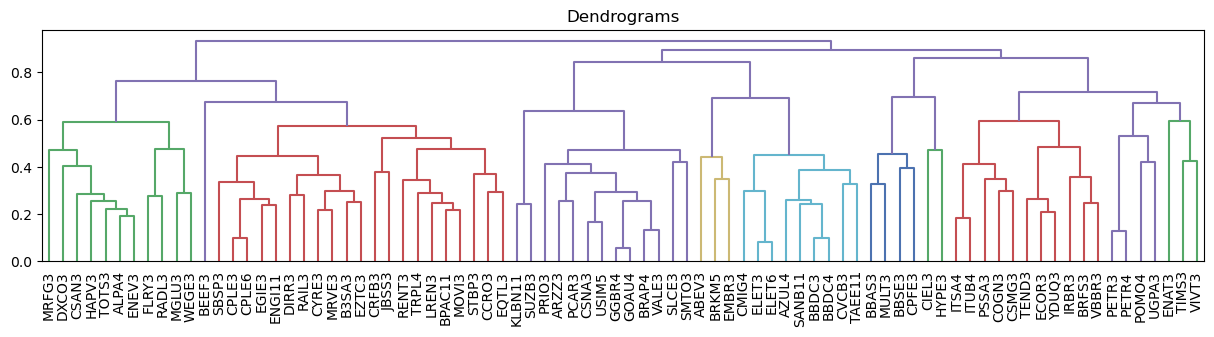

'\n##### using portifoliopt()\nplt.figure(figsize=(20, 5))\nplotting.plot_dendrogram(hrp)\nplt.title("Dendrograms")\nplt.xticks(rotation=90,fontsize=15)\nplt.show()\n'

In [8]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15, 3))
plt.title("Dendrograms")
sch.dendrogram(hrp.clusters,above_threshold_color = 'C9',labels = hrp.tickers) # color_threshold=0.7*max(hrp.clusters[:,2])

plt.xticks(rotation=90,fontsize=10)
plt.show()

'''
##### using portifoliopt()
plt.figure(figsize=(20, 5))
plotting.plot_dendrogram(hrp)
plt.title("Dendrograms")
plt.xticks(rotation=90,fontsize=15)
plt.show()
'''

In [9]:
# Define the number of clusters

distance = 0.7*max(hrp.clusters[:,2]) #standard cutoff used in sch.dendrogram()
ind = sch.fcluster(hrp.clusters, distance, criterion='distance') # Extract cluster assignments
df_clusters = pd.DataFrame({'ticker': hrp.tickers, 'cluster': ind}).copy()
#t['cluster'].value_counts()
df_clusters.head()

,ticker,cluster
0,ABEV3,5
1,ALPA4,1
2,ARZZ3,4
3,AZUL4,6
4,B3SA3,2


##### Exploring the clusters from the companies sectors perspectives

In [10]:
# Lets upload all brazilians listed companies sectors and assign is sectors to the tickes on each cluster
conn = sqlite3.connect(os.getenv('MY_FINANCE_DB_PATH')+'/finance_database.db') #this data source can be found here: https://github.com/Lucasantos77/capital_market_explorer/blob/master/data_scraping/B3_companies_sectors/get_br_companies_sectors.ipynb
cursor = conn.cursor()
cursor.execute(''' SELECT ticker_root,
                            segment,
                            economic_sector,
                            subsector
                            FROM B3_companies_sectors
                            GROUP BY ticker_root,
                            segment,
                            economic_sector,
                            subsector
            ''') # reading the companies sectors from my local SQLite database
rows = cursor.fetchall()
columns = [description[0] for description in cursor.description]

df_sectors = pd.DataFrame(rows, columns=columns)
#conn.close() 

# merge tickers clustered with its sectors
df_clusters['ticker_root'] = df_clusters['ticker'].str[:4]
df_clusters = pd.merge(df_clusters,df_sectors[['ticker_root','economic_sector']], on = 'ticker_root', how='left')

df_clusters.head()

,ticker,cluster,ticker_root,economic_sector
0,ABEV3,5,ABEV,Consumo não Cíclico
1,ALPA4,1,ALPA,Consumo Cíclico
2,ARZZ3,4,ARZZ,Consumo Cíclico
3,AZUL4,6,AZUL,Bens Industriais
4,B3SA3,2,B3SA,Financeiro


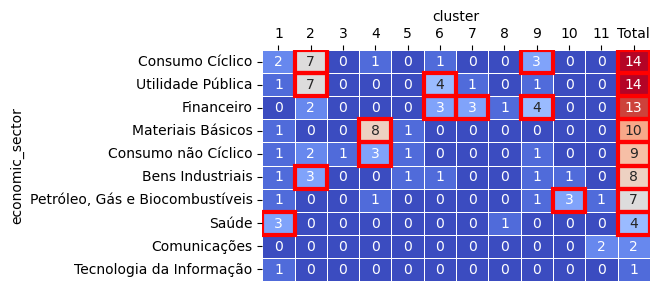

In [11]:
####### build a cross table to extract the amount of ticker in each cluster and sector

df_sec_clust = pd.crosstab(df_clusters['economic_sector'], df_clusters['cluster'])
df_sec_clust['Total'] = df_sec_clust.sum(axis =1)
df_sec_clust.sort_values(by='Total', ascending=False, inplace = True)

# Create a custom colormap where values >= 3 are highlighted
cmap = sns.color_palette("coolwarm", as_cmap=True)

# Plot heatmap
plt.figure(figsize=(5, 3))
ax = sns.heatmap(df_sec_clust, annot=True, fmt='d', cmap=cmap, cbar=False, 
                 linewidths=.5, linecolor='white')

# Highlight cells with values greater than 3
for i in range(df_sec_clust.shape[0]):
    for j in range(df_sec_clust.shape[1]):
        if df_sec_clust.iat[i, j] >= 3:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=3))

# Move x-ticks and labels above the heatmap
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticks_position('top')

# Set the title
#plt.title('Amount of tickers grouped on each cluster per economic sector', fontsize=8)
plt.show()

By highlighting the economic sectors with more than three tickers per cluster, we can see that the clustering effectively grouped tickers from the same sectors. For instance, Cluster 2 includes Consumer Cyclicals, Public Utilities, and Industrial Goods; Cluster 4 contains Public Utilities and Finance; and Cluster 7 is focused on Finance.

<a id="7"></a>
## Step 2 - Step 2 - Quasi-Diagonalisation (Matrix seriation)
[←](#0)

###### Calculating a correlation matrix sorted by the clusters obtained before

In [12]:
corr = data_ret.corr() # original covariance matrix
df_clusters.sort_values(by = ['cluster'], ascending = True, inplace = True) # sorting tickers by clusters
sorted_tickers = df_clusters['ticker'].values 

corr_sorted = corr.loc[sorted_tickers, sorted_tickers] #sorting the covariance matrix by clusters (Matrix Seriation)

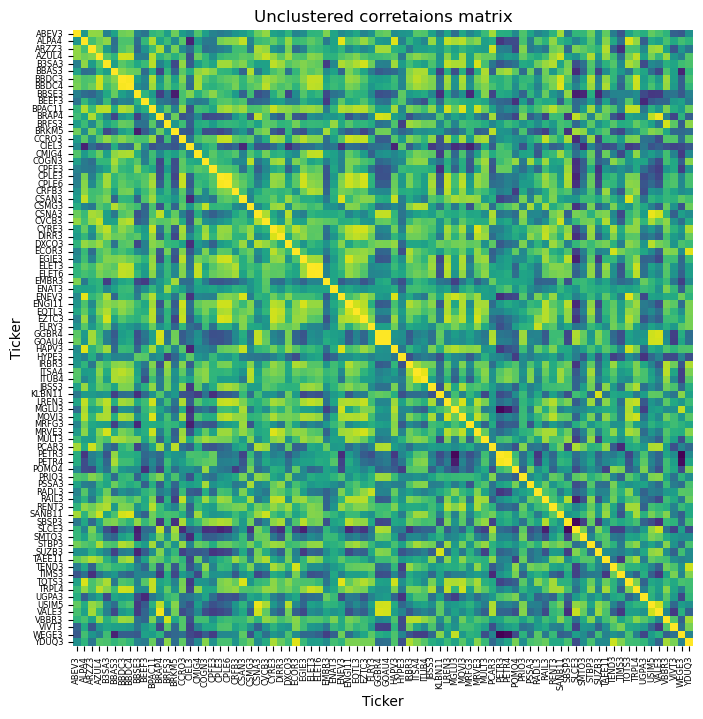

In [13]:
## Ploting the Unclustered Matrix
plt.figure(figsize=(8, 8))

ax = sns.heatmap(corr, cmap='viridis', cbar=False,xticklabels=True, yticklabels=True)

plt.title("Unclustered corretaions matrix")
plt.xticks(rotation=90,fontsize=6)
plt.yticks(rotation=0,fontsize=6)
plt.show()

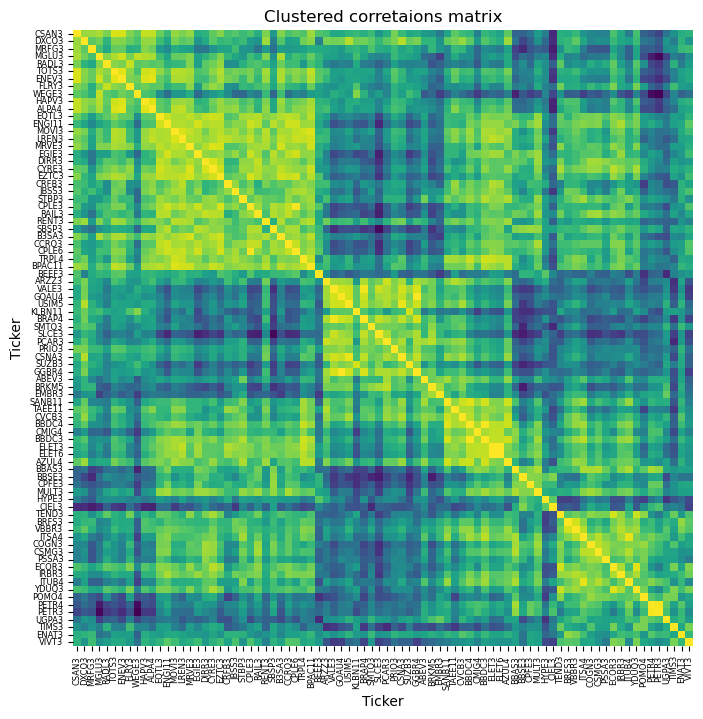

In [14]:
# Ploting the Clustered Matrix

plt.figure(figsize=(8, 8))

ax = sns.heatmap(corr_sorted, cmap='viridis', cbar=False,xticklabels=True, yticklabels=True)
plt.title("Clustered corretaions matrix")

plt.xticks(rotation=90,fontsize=6)
plt.yticks(rotation=0,fontsize=6)

plt.show()

The images above displays the seriated correlation matrix for our data. Initially, the asset clusters are fragmented into smaller sub-sections, but after quasi-diagonalizing or seriating the matrix, the clustering structure becomes much clearer.

<a id="8"></a>
###  Step 3 - Recursive Bisection and weighting
[←](#0)


**Bisection of Clusters:** Starting with the entire portfolio, the first step is to split it into two clusters. These two clusters are then treated as two "sub-portfolios".

**Weight Assignment:** The total portfolio variance is minimized by assigning weights between these two clusters. The weight given to each cluster is proportional to the inverse of the sum of the variances of the assets within each cluster. For example, if Cluster A has a lower variance than Cluster B, Cluster A will receive a higher weight.

**Further Splitting:** Each of these two clusters is then recursively split further into smaller clusters, and the process of weight allocation is repeated at each level. At every step, the sub-cluster variances are used to determine the weights.

**Final Allocation:** The process continues until the algorithm reaches the individual assets. By the end of the Recursive Bisection, each asset has a weight assigned to it. This weight reflects the hierarchical structure of the clusters and aims to allocate risk more effectively across the portfolio.


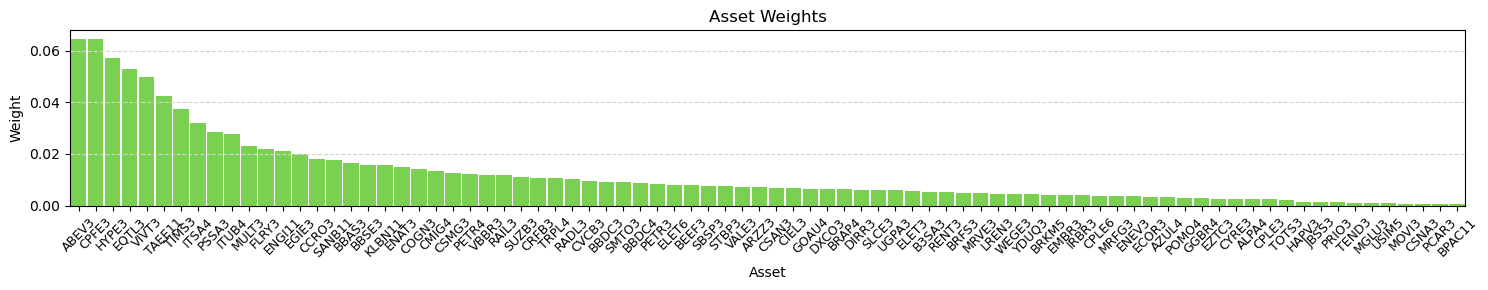

In [15]:
dfw = pd.DataFrame(list(hrp_weights.items()), columns=['Asset', 'Weight'])
dfw.head()

dfw = dfw.sort_values(by='Weight', ascending=False)

# Plot the bar graph
plt.figure(figsize=(15, 3))
plt.bar(dfw['Asset'], dfw['Weight'], color='#7AD151FF',width=0.9)
plt.grid(visible=True, which='major', axis='y', linestyle='--', color='lightgray')

plt.xlabel('Asset')
plt.ylabel('Weight')
plt.title('Asset Weights')
plt.xticks(rotation=45,fontsize=9)
plt.xlim(-0.5,len(dfw) -0.5)
plt.tight_layout()

plt.show()

The result is a set of asset weights that take into account the hierarchical relationships between assets, reducing the concentration of risk and leading to a more diversified portfolio.


<a id="9"></a>
# Backtesting the strategy
[←](#0)

<a id="10"></a>
## Selecting top 10 assets for each month by its previous returns (Momentum)

##### calculating the twelve months returns daily

In [16]:
# change the pre processed dataframe from wide to long
data['time'] = data.index
data = pd.melt(data, id_vars = ['time'], var_name = 'Ticker', value_name = 'price') 
data.rename(columns = {'Ticker':'asset'}, inplace = True)
data.head()

,time,asset,price
0,2018-04-26,ABEV3,18.589228
1,2018-04-27,ABEV3,18.485554
2,2018-04-30,ABEV3,18.605177
3,2018-05-02,ABEV3,18.078840
4,2018-05-03,ABEV3,18.023016


In [17]:
# grouping ticker and calculate return 12m and lagged price

data['lagged_price'] = data.groupby('asset')['price'].shift() #lagged price
data['return12m'] = data.groupby('asset')['price'].transform(lambda x: x / x.shift(252) - 1) #returns 12 month 

data.head()

,time,asset,price,lagged_price,return12m
0,2018-04-26,ABEV3,18.589228,NaN,NaN
1,2018-04-27,ABEV3,18.485554,18.589228,NaN
2,2018-04-30,ABEV3,18.605177,18.485554,NaN
3,2018-05-02,ABEV3,18.078840,18.605177,NaN
4,2018-05-03,ABEV3,18.023016,18.078840,NaN


###### Getting last days rows over month

In [18]:
# transform to date time format
data['time'] = pd.to_datetime(data['time'])

#groupping by asset ticker and month
groups = data.groupby(['asset', data['time'].dt.to_period('M')])

# using the idxmax() function to get the maximum index (last day) of each group ticker-month group
idx = groups['time'].idxmax()

# filtering data prices only at the last day of each ticker-month group
data_montly = data.loc[idx]

data_montly.head()

,time,asset,price,lagged_price,return12m
2,2018-04-30,ABEV3,18.605177,18.485554,NaN
23,2018-05-30,ABEV3,15.702353,15.622606,NaN
44,2018-06-29,ABEV3,14.462273,14.486405,NaN
65,2018-07-31,ABEV3,15.612501,15.845763,NaN
88,2018-08-31,ABEV3,15.162064,15.282716,NaN



##### Selecting top 10 tickers with bigger returns 

In [19]:
# Creating Year-Month column
data_montly['Yearmon'] = data_montly['time'].dt.to_period('M')

# Rank over each month what was the ticker which had the biggest 12 month return
data_montly['rank_return'] = data_montly.groupby('Yearmon')['return12m'].rank(ascending = False)
# selecting the top 25 bigger returns
top_10_returns = data_montly[data_montly['rank_return'].between(1,10)].reset_index(drop = True)

top_10_returns.head()

,time,asset,price,lagged_price,return12m,Yearmon,rank_return
0,2019-08-30,ALPA4,24.450226,24.568632,1.589883,2019-08,9.0
1,2019-09-30,ALPA4,25.555323,25.456654,1.812771,2019-09,3.0
2,2019-10-31,ALPA4,26.877491,27.262302,1.270000,2019-10,8.0
3,2019-11-29,ALPA4,31.357073,30.883461,1.637782,2019-11,4.0
4,2019-12-30,ALPA4,32.758175,32.225361,1.515151,2019-12,6.0


In [20]:
#the portifolios is rebalanced every 1st day from each month
top_10_returns['time1'] = pd.to_datetime(top_10_returns['time']) + pd.DateOffset(months = 1) 
top_10_returns['Yearmon_c'] = top_10_returns['time1'].dt.to_period('M') # corrected year month date to consider the montly rebalancing

#df1 = top_10_returns #saving for excel analysis
top_10_returns.head()

,time,asset,price,lagged_price,return12m,Yearmon,rank_return,time1,Yearmon_c
0,2019-08-30,ALPA4,24.450226,24.568632,1.589883,2019-08,9.0,2019-09-30,2019-09
1,2019-09-30,ALPA4,25.555323,25.456654,1.812771,2019-09,3.0,2019-10-30,2019-10
2,2019-10-31,ALPA4,26.877491,27.262302,1.270000,2019-10,8.0,2019-11-30,2019-11
3,2019-11-29,ALPA4,31.357073,30.883461,1.637782,2019-11,4.0,2019-12-29,2019-12
4,2019-12-30,ALPA4,32.758175,32.225361,1.515151,2019-12,6.0,2020-01-30,2020-01


In [21]:
top_10_returns = top_10_returns[['Yearmon_c','rank_return','asset']]
top_10_returns.head()

,Yearmon_c,rank_return,asset
0,2019-09,9.0,ALPA4
1,2019-10,3.0,ALPA4
2,2019-11,8.0,ALPA4
3,2019-12,4.0,ALPA4
4,2020-01,6.0,ALPA4


In [22]:
# preparing daily price to build a join with top 10 data frame of selected assets
data['time'] = pd.to_datetime(data['time'])
data['Yearmon_c'] = data['time'].dt.to_period('M')

# inner join to select daily prices only for top 10 tickers performances over each month
data = pd.merge(data,top_10_returns[['Yearmon_c','rank_return','asset']], how = 'inner', on = ['Yearmon_c','asset'])
#df2 = data #saving for excel analysis
data.head()

,time,asset,price,lagged_price,return12m,Yearmon_c,rank_return
0,2019-09-02,ALPA4,24.272623,24.450226,1.504072,2019-09,9.0
1,2019-09-03,ALPA4,23.542473,24.272623,1.424797,2019-09,9.0
2,2019-09-04,ALPA4,23.433937,23.542473,1.429419,2019-09,9.0
3,2019-09-05,ALPA4,23.285933,23.433937,1.350598,2019-09,9.0
4,2019-09-06,ALPA4,22.693916,23.285933,1.265563,2019-09,9.0


<a id="11"></a>
## Calculating the portifolio quota
[←](#0)

In [23]:
# calculating portifolio quota price per ticker

data['return_group'] = data.groupby('rank_return') \
                       .apply(lambda group: (group['price'] / group['lagged_price']) - 1) \
                       .reset_index(level = 0, drop = True) 

data['quota'] = data.groupby(['rank_return','Yearmon_c'])['return_group'].transform(lambda x: (1 + x ).cumprod()) # cumulative return over rank (ticker) and month
#df3 = data #saving for excel analysis
data.head()

,time,asset,price,lagged_price,return12m,Yearmon_c,rank_return,return_group,quota
0,2019-09-02,ALPA4,24.272623,24.450226,1.504072,2019-09,9.0,-0.007264,0.992736
1,2019-09-03,ALPA4,23.542473,24.272623,1.424797,2019-09,9.0,-0.030081,0.962873
2,2019-09-04,ALPA4,23.433937,23.542473,1.429419,2019-09,9.0,-0.004610,0.958434
3,2019-09-05,ALPA4,23.285933,23.433937,1.350598,2019-09,9.0,-0.006316,0.952381
4,2019-09-06,ALPA4,22.693916,23.285933,1.265563,2019-09,9.0,-0.025424,0.928168


<a id="12"></a>
## Calculating the HRP over the montly portifolios selected
[←](#0)

In [24]:
data.head(2)

,time,asset,price,lagged_price,return12m,Yearmon_c,rank_return,return_group,quota
0,2019-09-02,ALPA4,24.272623,24.450226,1.504072,2019-09,9.0,-0.007264,0.992736
1,2019-09-03,ALPA4,23.542473,24.272623,1.424797,2019-09,9.0,-0.030081,0.962873


##### calculating the HRP over every month assets selected by its momentum performance 

In [25]:
df_top10yearmon = data.pivot(index=['time','Yearmon_c'], columns='rank_return', values='return12m').reset_index()

N = np.sort(data['Yearmon_c'].unique()).tolist()

df_weights_final = pd.DataFrame()
for yearmon_c in N:
    temp = df_top10yearmon[df_top10yearmon['Yearmon_c'] == yearmon_c] #temporary dataframe to hold the retuns on a filtered yearmon for all assets
    
    ## calculating the HRP wheights for each yearmon portifolio
    hrp = HRPOpt(temp.iloc[:,2:])
    hrp_weights = hrp.optimize(linkage_method="complete")

    ## saving and appending the weights 
    df_weights = pd.DataFrame(list(hrp_weights.items()), columns=['ranked_asset', 'Weight'])
    df_weights['key_Rank_Yearmon_c'] = df_weights['ranked_asset'].astype(int).astype(str)+'_'+yearmon_c.strftime('%Y-%m') # creating a key to join the weights with its correspondent yearmon and asset

    df_weights_final = pd.concat([df_weights_final, df_weights])
    

In [26]:
## assigning the weights pre calculed by HRP into the daily data using the key columns 'Rank' (asset) and 'Yearmon_c'
data['key_Rank_Yearmon_c'] = data['rank_return'].astype(int).astype(str)+'_'+data['Yearmon_c'].dt.strftime('%Y-%m')
data = pd.merge(data,df_weights_final[['Weight','key_Rank_Yearmon_c']], on = 'key_Rank_Yearmon_c', how = 'left')

data.head()

,time,asset,price,lagged_price,return12m,Yearmon_c,rank_return,return_group,quota,key_Rank_Yearmon_c,Weight
0,2019-09-02,ALPA4,24.272623,24.450226,1.504072,2019-09,9.0,-0.007264,0.992736,9_2019-09,0.049228
1,2019-09-03,ALPA4,23.542473,24.272623,1.424797,2019-09,9.0,-0.030081,0.962873,9_2019-09,0.049228
2,2019-09-04,ALPA4,23.433937,23.542473,1.429419,2019-09,9.0,-0.004610,0.958434,9_2019-09,0.049228
3,2019-09-05,ALPA4,23.285933,23.433937,1.350598,2019-09,9.0,-0.006316,0.952381,9_2019-09,0.049228
4,2019-09-06,ALPA4,22.693916,23.285933,1.265563,2019-09,9.0,-0.025424,0.928168,9_2019-09,0.049228


##### Ploting a sample of some portifolios montly weighted by HRP and equaly weighted

In [27]:
# preparing the dataframe to plot
t = data.groupby(['Yearmon_c','asset'])['Weight'].first().to_frame().reset_index().sort_values(by = ['Yearmon_c','Weight'], ascending = False).reset_index(drop = True).copy()
t['Weight_HRP'] = t['Weight']*100 # HRP weighted in %
t['Weight_Equal'] = 10 # equal weighted 10%

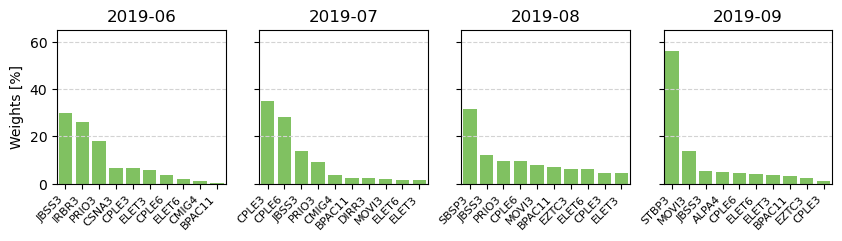

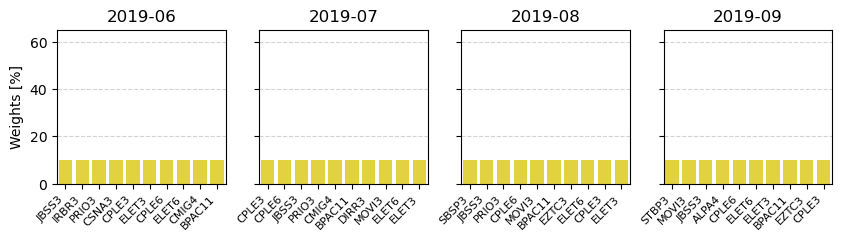

In [28]:
def ploting_portifolios(df,nmonths,yvar,xvar,barcolor):
    
    unique_months = df['Yearmon_c'].unique()[::-1][:nmonths] #selecting X months to plot the portifolios
    fig, axs = plt.subplots(1, len(unique_months), figsize=(10, 2), sharex=False)
    
    for i, month in enumerate(unique_months):

        sorted_data =  df[df['Yearmon_c'] == month].sort_values(by=yvar, ascending=False).reset_index(drop=True)
        #sorted_data.plot(kind='bar', x='asset', y='Weight', ax=axs[i], color='#7AD151FF', legend=False,width=0.8)
        sns.barplot(x=xvar, y=yvar, data=sorted_data,ax=axs[i], color= barcolor) 

        #axs[i].set_xticks(range(len(sorted_data)))  # This ensures the correct number of ticks
        axs[i].set_xticklabels(sorted_data[xvar], rotation=45, ha='right', fontsize=8)

        # grid title and ylimit
        axs[i].grid(visible=True, which='major', axis='y', linestyle='--', color='lightgray')
        axs[i].set_title(month)
        axs[i].set_ylim(0, 65)

        #labels
        axs[i].set_xlabel('')  # This removes the x-axis label
        axs[i].set_ylabel('')  # This removes the x-axis label
        if i == 0: axs[i].set_ylabel('Weights [%]')  # Optionally, add a y-axis label
        else: axs[i].set_yticklabels([])  # Remove y-tick labels for other subplots

# ploting graphs
ploting_portifolios(t,4,'Weight_HRP','asset','#7AD151FF')
ploting_portifolios(t,4,'Weight_Equal','asset','#FDE725FF')

<a id="13"></a>
## Backtesting by HRP weights method
[←](#0)

###### Calculating final portifolio quota for all ticker using the weights pre calculated 

In [29]:
data['quota_weighted'] = data['quota']*data['Weight']

data_long_HRP = (
    data.groupby('time') # for each day, calculate the portifolio quota considering the 10 assets equally weighted
    .agg(quota_long_HRP = ('quota_weighted', lambda x: x.sum()))
    .reset_index())
df4 = data_long_HRP  #saving for excel analysis
data_long_HRP.head()

,time,quota_long_HRP
0,2019-06-03,0.985908
1,2019-06-04,1.007897
2,2019-06-05,0.985880
3,2019-06-06,0.982716
4,2019-06-07,0.985607


##### Compound portifolio returns over time

In [30]:
data_long_HRP['Yearmon'] = data_long_HRP['time'].dt.to_period('M')
data_long_HRP['order'] = data_long_HRP.groupby('Yearmon')['time'].rank()

#  calculating the portfolio returns over time considering the portifolios is rebalanced every month
data_long_HRP['return_long_HRP'] = data_long_HRP.apply(lambda row: row['quota_long_HRP'] - 1.0 if row['order'] == 1 else row['quota_long_HRP']/data_long_HRP.loc[row.name-1,'quota_long_HRP'] - 1, axis = 1)

# calculating the cumulative return over the entire period
data_long_HRP['quota_portifolio_HRP'] = (1+data_long_HRP['return_long_HRP']).cumprod()
#df5 = data_long_HRP #saving for excel analysis

data_long_HRP.set_index(['time'], inplace = True)

data_long_HRP.tail()

,quota_long_HRP,Yearmon,order,return_long_HRP,quota_portifolio_HRP
time,,,,,
2024-06-24,1.023634,2024-06,16.0,0.016199,2.107516
2024-06-25,1.027708,2024-06,17.0,0.003980,2.115904
2024-06-26,1.036407,2024-06,18.0,0.008465,2.133816
2024-06-27,1.060530,2024-06,19.0,0.023276,2.183481
2024-06-28,1.049412,2024-06,20.0,-0.010484,2.160590


<a id="14"></a>
## Backtesting by Equal Weighted method
[←](#0)

In [31]:
data_long_EW = (
    data.groupby('time') # for each day, calculate the portifolio quota considering the 10 assets equally weighted
    .agg(quota_long_EW = ('quota', lambda x: x.sum()/len(x)))
    .reset_index())
#df4 = data_long_EW  #saving for excel analysis
data_long_EW.head()

,time,quota_long_EW
0,2019-06-03,0.993253
1,2019-06-04,1.007470
2,2019-06-05,0.990391
3,2019-06-06,1.002854
4,2019-06-07,1.005496


In [32]:
data_long_EW['Yearmon'] = data_long_EW['time'].dt.to_period('M')
data_long_EW['order'] = data_long_EW.groupby('Yearmon')['time'].rank()

#  calculating the portfolio returns over time considering the portifolios is rebalanced every month
data_long_EW['return_long_EW'] = data_long_EW.apply(lambda row: row['quota_long_EW'] - 1.0 if row['order'] == 1 else row['quota_long_EW']/data_long_EW.loc[row.name-1,'quota_long_EW'] - 1, axis = 1)

# calculating the cumulative return over the entire period
data_long_EW['quota_portifolio_EW'] = (1+data_long_EW['return_long_EW']).cumprod()
#df5 = data_long_EW #saving for excel analysis

data_long_EW.set_index(['time'], inplace = True)

data_long_EW.tail()

,quota_long_EW,Yearmon,order,return_long_EW,quota_portifolio_EW
time,,,,,
2024-06-24,1.013339,2024-06,16.0,0.014109,2.051443
2024-06-25,1.012128,2024-06,17.0,-0.001195,2.048992
2024-06-26,1.019468,2024-06,18.0,0.007252,2.063851
2024-06-27,1.051617,2024-06,19.0,0.031535,2.128936
2024-06-28,1.044717,2024-06,20.0,-0.006562,2.114966


<a id="15"></a>

# Comparing results
[←](#0)

##### Download and calculation of Ibovespa returns

In [33]:
bench_list = ['^BVSP']
df_benchmk = yf.download(bench_list, start = '2019-05-31', end = end_date)['Adj Close'].to_frame().rename(columns = {'Adj Close':'ibov'})
df_benchmk.head()

[*********************100%%**********************]  1 of 1 completed


,ibov
Date,
2019-05-31,97030.0
2019-06-03,97020.0
2019-06-04,97380.0
2019-06-05,95999.0
2019-06-06,97205.0


In [34]:
df_benchmk['ibov_returns'] = df_benchmk['ibov'].pct_change() # ibovespa daily returns
df_benchmk['ibov_cumm_return'] = (1+df_benchmk['ibov_returns']).cumprod() # ibovespa cummulative returns
df_benchmk.head()

,ibov,ibov_returns,ibov_cumm_return
Date,,,
2019-05-31,97030.0,NaN,NaN
2019-06-03,97020.0,-0.000103,0.999897
2019-06-04,97380.0,0.003711,1.003607
2019-06-05,95999.0,-0.014182,0.989374
2019-06-06,97205.0,0.012563,1.001804


<a id="16"></a>
## Final returns
[←](#0)

In [35]:
# concatenating results columns from both methods HRP and Equal Weighted portifolios
df_port_ret = pd.concat([data_long_EW['quota_portifolio_EW'],
                         data_long_EW['return_long_EW'],
                         data_long_HRP['quota_portifolio_HRP'],
                         data_long_HRP['return_long_HRP']], axis=1)
df_port_ret.columns = ['quota_portifolio_EW','return_long_EW', 'quota_portifolio_HRP','return_long_HRP']
df_port_ret.tail()

,quota_portifolio_EW,return_long_EW,quota_portifolio_HRP,return_long_HRP
time,,,,
2024-06-24,2.051443,0.014109,2.107516,0.016199
2024-06-25,2.048992,-0.001195,2.115904,0.003980
2024-06-26,2.063851,0.007252,2.133816,0.008465
2024-06-27,2.128936,0.031535,2.183481,0.023276
2024-06-28,2.114966,-0.006562,2.160590,-0.010484


In [36]:
# merging Ibovespa with calculated portifolio returns
df_port_ret = pd.merge(df_port_ret, df_benchmk[['ibov_cumm_return','ibov_returns']], left_index=True, right_index=True)
df_port_ret.head()

,quota_portifolio_EW,return_long_EW,quota_portifolio_HRP,return_long_HRP,ibov_cumm_return,ibov_returns
2019-06-03,0.993253,-0.006747,0.985908,-0.014092,0.999897,-0.000103
2019-06-04,1.007470,0.014313,1.007897,0.022304,1.003607,0.003711
2019-06-05,0.990391,-0.016952,0.985880,-0.021845,0.989374,-0.014182
2019-06-06,1.002854,0.012583,0.982716,-0.003210,1.001804,0.012563
2019-06-07,1.005496,0.002635,0.985607,0.002942,1.008152,0.006337


#### Cumulative returns graph

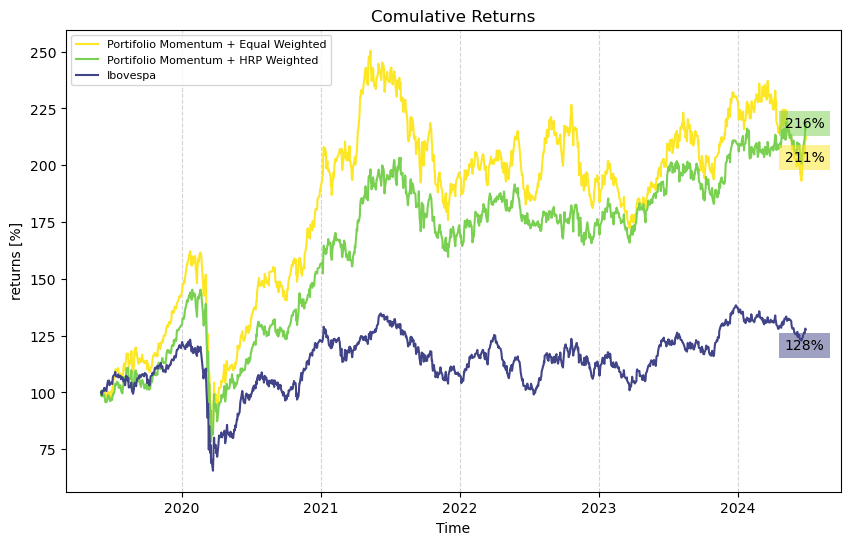

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(df_port_ret.index,df_port_ret['quota_portifolio_EW']*100, label = 'Portifolio Momentum + Equal Weighted', color='#FDE725FF')
plt.plot(df_port_ret.index,df_port_ret['quota_portifolio_HRP']*100, label = 'Portifolio Momentum + HRP Weighted', color='#7AD151FF')
plt.plot(df_port_ret.index,df_port_ret['ibov_cumm_return']*100, label = 'Ibovespa', color='#414487FF')

plt.grid(visible=True, which='major', axis='x', linestyle='--', color='lightgray')

# print the final return as text box
yp_last_EW = round(df_port_ret['quota_portifolio_EW'].iloc[-1]*100) # finding the exact y-coordinate to the text box
yp_last_HRP = round(df_port_ret['quota_portifolio_HRP'].iloc[-1]*100)
yibov_last = round(df_port_ret['ibov_cumm_return'].iloc[-1]*100)

# plot and customizer the text box
plt.annotate(f'{yp_last_EW}%', xy=( df_port_ret.index[-1], yp_last_EW), xytext=(-15, -15),textcoords='offset points', color='black',
            bbox=dict(facecolor='#FDE725FF', alpha=0.5, edgecolor='none'))

plt.annotate(f'{yp_last_HRP}%', xy=( df_port_ret.index[-1], yp_last_HRP+10), xytext=(-15, -15),textcoords='offset points', color='black',
            bbox=dict(facecolor='#7AD151FF', alpha=0.5, edgecolor='none'))

plt.annotate(f'{yibov_last}%', xy=( df_port_ret.index[-1], yibov_last), xytext=(-15,-15),textcoords='offset points', color='black',
            bbox=dict(facecolor='#414487FF', alpha=0.5, edgecolor='none'))

# Writing title and axis names
plt.title('Comulative Returns')
plt.xlabel('Time')
plt.ylabel('returns [%]')
plt.legend(prop={'size': 8}) 

<a id="17"></a>
## Daily volatility
[←](#0)

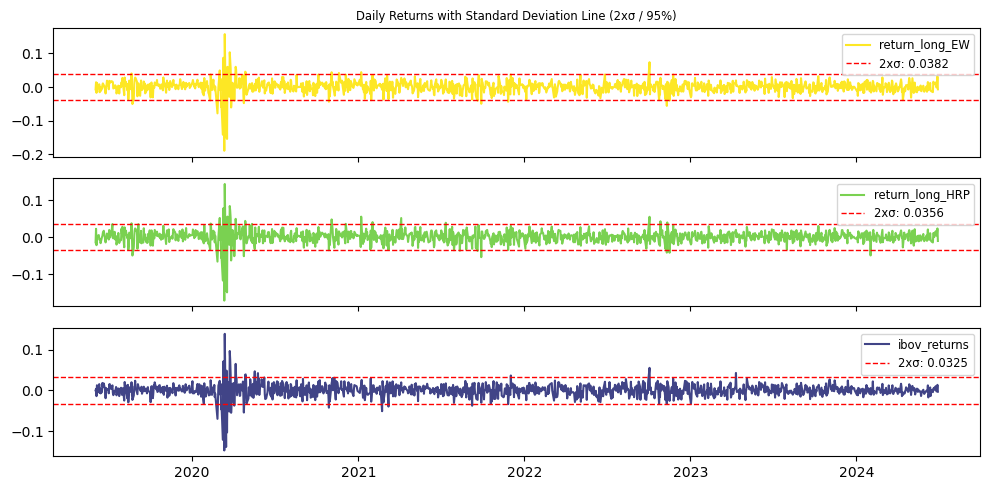

In [38]:
# calculating the 95% (2 x std) of each portifolio daily returns
df_plot = df_port_ret[['return_long_EW','return_long_HRP','ibov_returns']].copy()
std_devs = df_plot.std()*2
# defining the color coding
colors = {'ibov_returns': '#414487FF','return_long_HRP': '#7AD151FF','return_long_EW': '#FDE725FF'}

# Plotting all the daily returns and standar deviation lines
fig, axs = plt.subplots(3, 1, figsize=(10, 5), sharex=True)

for i, asset in enumerate(df_plot.columns):
    axs[i].plot(df_plot.index, df_plot[asset], label= df_plot.columns[i], color=colors[asset])
    axs[i].axhline(y=std_devs[asset], color='r', linestyle='--', linewidth=1, label=f'2x\u03C3: {std_devs[asset]:.4f}')
    axs[i].axhline(y=-std_devs[asset], color='r', linestyle='--', linewidth=1)
    if i==0: axs[i].set_title(f'Daily Returns with Standard Deviation Line (2x\u03C3 / 95%)',fontsize='small')
    axs[i].legend(fontsize='small', loc = 'upper right')
    

plt.tight_layout()
plt.show()

<a id="18"></a>
## Anualized volatility
[←](#0)

In [39]:
df_plot['time'] = pd.to_datetime(df_plot.index)
df_plot['Yearmon'] = df_plot['time'].dt.to_period('M')
df_plot.head(2)

,return_long_EW,return_long_HRP,ibov_returns,time,Yearmon
2019-06-03,-0.006747,-0.014092,-0.000103,2019-06-03,2019-06
2019-06-04,0.014313,0.022304,0.003711,2019-06-04,2019-06


[%] total anualized volatility in the period (2019-2024):
Portifolio Momentum + Equal Weighted: 30.30%
Portifolio Momentum + HRP Weighted: 28.20%
Ibovespa: 25.80%


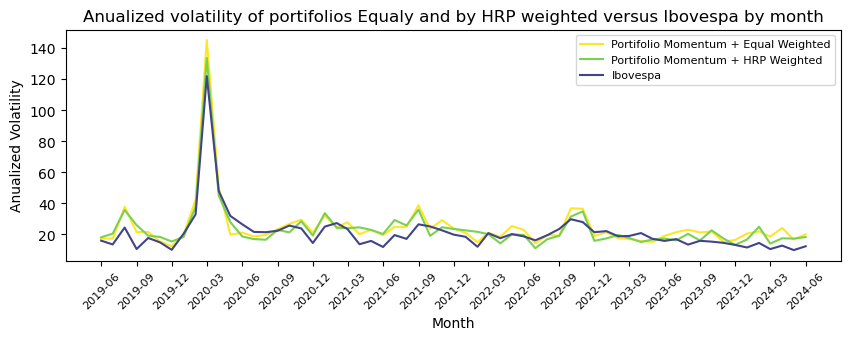

In [40]:
# Calculating anualized volatility per month
t1 = df_plot.groupby('Yearmon')[['return_long_EW','return_long_HRP','ibov_returns']].std().rename(columns = {'return_long_EW':'vol_Equal_Weighted',
                                                                                                             'return_long_HRP':'vol_HRP',
                                                                                                             'ibov_returns':'vol_ibovespa'}) * np.sqrt(252) *100
t1 = t1.reset_index()
t1['Yearmon'] = t1['Yearmon'].dt.to_timestamp()
t1.sort_values(by = ['Yearmon'], inplace = True)

####
# print total volatility
print('[%] total anualized volatility in the period (2019-2024):\nPortifolio Momentum + Equal Weighted: {:.2%}\nPortifolio Momentum + HRP Weighted: {:.2%}\nIbovespa: {:.2%}'
      .format(round(df_plot['return_long_EW'].std()*252**0.5,3),
              round(df_plot['return_long_HRP'].std()*252**0.5,3),
              round(df_plot['ibov_returns'].std()*252**0.5,3)))

#### ploting anualized volotatility per month
import matplotlib.dates as mdates

plt.figure(figsize=(10, 3))

plt.plot(t1['Yearmon'],t1['vol_Equal_Weighted'], label = 'Portifolio Momentum + Equal Weighted', color='#FDE725FF')
plt.plot(t1['Yearmon'],t1['vol_HRP'], label = 'Portifolio Momentum + HRP Weighted', color='#7AD151FF')
plt.plot(t1['Yearmon'],t1['vol_ibovespa'], label = 'Ibovespa', color='#414487FF')

# ajusting x-ticks 
locator = mdates.MonthLocator(bymonth=[3, 6, 9, 12]) 
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().tick_params(axis='x', rotation=45, labelsize=8)

plt.title('Anualized volatility of portifolios Equaly and by HRP weighted versus Ibovespa by month')
plt.xlabel('Month')
plt.ylabel('Anualized Volatility')
plt.legend(prop={'size': 8}) 

plt.show()


<a id="19"></a>
## Sharpe Ratio
[←](#0)

##### import SELIC, Brazilian Risk Free rate

In [41]:
conn = sqlite3.connect(os.getenv('MY_FINANCE_DB_PATH')+'/finance_database.db') #this data source can be found here: http://localhost:8888/notebooks/OneDrive/CM_Explorer/data_scraping/BACEN_risk_free_rate/BACEN_risk_free_rate.ipynb
cursor.execute(''' SELECT ReferenceDate as 'time',
                    "Year-Month",
                    "Year",
                    SELIC_DAY, SELIC_YEAR
                    FROM BACEN_risk_free_rate
            ''') # reading the companies sectors from my local SQLite database
rows = cursor.fetchall()
columns = [description[0] for description in cursor.description]


df_risk_free = pd.DataFrame(rows, columns=columns)
conn.close() 

In [42]:
df_risk_free['time'] = pd.to_datetime(df_risk_free['time'])
df_plot = pd.merge(df_plot,df_risk_free[['time','SELIC_DAY','SELIC_YEAR']], how = 'left', on = 'time')
df_plot.head(2)

,return_long_EW,return_long_HRP,ibov_returns,time,Yearmon,SELIC_DAY,SELIC_YEAR
0,-0.006747,-0.014092,-0.000103,2019-06-03,2019-06,0.02462,0.063999
1,0.014313,0.022304,0.003711,2019-06-04,2019-06,0.02462,0.063999


In [43]:
# Function to calculate Sharpe Ratio
def calculate_sharpe_ratio(returns, risk_free):
    excess_returns = returns - risk_free
    mean_excess_return = excess_returns.mean()
    std_dev_excess_return = excess_returns.std()
    return mean_excess_return / std_dev_excess_return

# Calculate Sharpe Ratio for each portfolio
sharpe_ratio_EW = calculate_sharpe_ratio(df_plot['return_long_EW'], df_plot['SELIC_DAY'])
sharpe_ratio_HRP = calculate_sharpe_ratio(df_plot['return_long_HRP'], df_plot['SELIC_DAY'])
sharpe_ratio_Ibov = calculate_sharpe_ratio(df_plot['ibov_returns'], df_plot['SELIC_DAY'])

print(f"Sharpe Ratio for Equal Weighted: {sharpe_ratio_EW:.2f}")
print(f"Sharpe Ratio for HRP: {sharpe_ratio_HRP:.2f}")
print(f"Sharpe Ratio for Ibovespa: {sharpe_ratio_Ibov:.2f}")

Sharpe Ratio for Equal Weighted: -1.17
Sharpe Ratio for HRP: -1.22
Sharpe Ratio for Ibovespa: -1.31


##### ploting share ratios chart

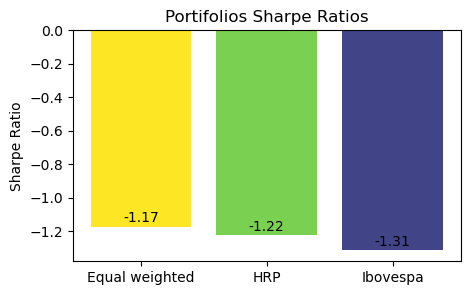

In [44]:
sharpe_ratios = {
    'Equal weighted': sharpe_ratio_EW,
    'HRP': sharpe_ratio_HRP,
    'Ibovespa': sharpe_ratio_Ibov}

# Extract the names and values for plotting
names = list(sharpe_ratios.keys())
values = list(sharpe_ratios.values())

# Create a bar plot
plt.figure(figsize=(5, 3))
bars = plt.bar(names, values, color=['#FDE725FF', '#7AD151FF', '#414487FF'])

# Add labels above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

# Add titles and labels
plt.title('Portifolios Sharpe Ratios')
plt.ylabel('Sharpe Ratio')

# Show plot
plt.show()

<a id="19"></a>
# Comments and further discussion
[←](#0)

- **Conclusions:**

In terms of total returns, and considering most time windows within the entire period, the portfolio strategy using momentum and HRP (Hierarchical Risk Parity) weights generally underperformed compared to the equal-weighted portfolio. However, by the end of the period, the HRP strategy achieved an accumulated return of 216%, slightly surpassing the 211% return of the equal-weighted strategy. Both strategies significantly outperformed the Ibovespa benchmark, indicating the effectiveness of the momentum factor in generating alpha.

When comparing the Sharpe Ration of the both startegy, the HRP-weighted portfolio slightly underperformed the equal-weighted strategy, with a Sharpe ratio of -1.22 compared to -1.17 from EW.

The conclusion of this study suggests that applying the HRP technique to a momentum portfolio on a monthly rolling window **does not seem to add substantial** value when weighed against its complexity compared to a simple equal-weighted approach. These results align with findings from other studies in the literature like Miguel Garlappi in Optimal Versus Naive Diversification: How Inefficient is the 1/N Portfolio Strategy? from 2009.


- **Further improvements:**

There are some issues with the implementation code on this study that can be addressed in the future improvements, such as:

**Survivorship bias:** Since we backtested only over the IBrX100 tickers as of July 2024, many tickers that were previously in the index are no longer present for various reasons, such as company bankruptcy, corporate mergers, or companies exiting the exchange. To address this bias, it is possible to use the historical composition of the IBrX100 and, for each month, include the tickers that were actually in the index at each time frame.

**Anomalous Returns** Another shortcoming of the strategy is that companies with incredible performance during this period tend to skew the return results, such as MGLU3. To avoid this issue, we can apply a filter at the beginning to include only tickers under a certain realistic amount of return.
